In [1]:
from julia_strain_functions import iso_gatom_level_tr_strain, iso_gatom_ann_strain
from matplotlib import pyplot as plt
import numpy as np 

# Isolated Level Transition Strain
Below is the envelope for the level transition strain \
When the oscillatory term is added, it only shifts the frequency axis to the transition frequency \
The width of the strain envelope is entirely set by the transition rate

In [ ]:
result['omega_tr_GeV'] 

3.4451407454141036e-16

Max N_e ≈ 9.303e+57
Max N_g ≈ 3.662e+58
Max h(t) ≈ 2.148e-31
omega_tr ≈ 3.445e-16 GeV
gamma_sre_yr ≈ 1.680e+04 1/yr
gamma_srg_yr ≈ 1.532e+04 1/yr
gamma_t_yr  ≈ 1.678e-53 1/yr
gamma_sre_gev  ≈ 3.198e-28 1/Gev
Mu_a  ≈ 1.002e-13 GeV


/home/cherrytree/bosonSR_repo_/julia_strain_functions.py:348: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_lorentzian, f_fit, ydata, p0=p0, maxfev=20000)


Fitted center frequency f0   = 1.873602e-04 Hz
Fitted width gamma           = 2.818589e-04 Hz
Estimated FWHM ≃ 2*gamma     = 5.637178e-04 Hz
Fitted constant floor C      = 1.436e-41
dict_keys(['time_yr', 'h_t', 'N_e', 'N_g', 'f_pos', 'H_pos', 'L_full', 'lorentz_params', 'omega_tr_GeV', 'Mu_a'])


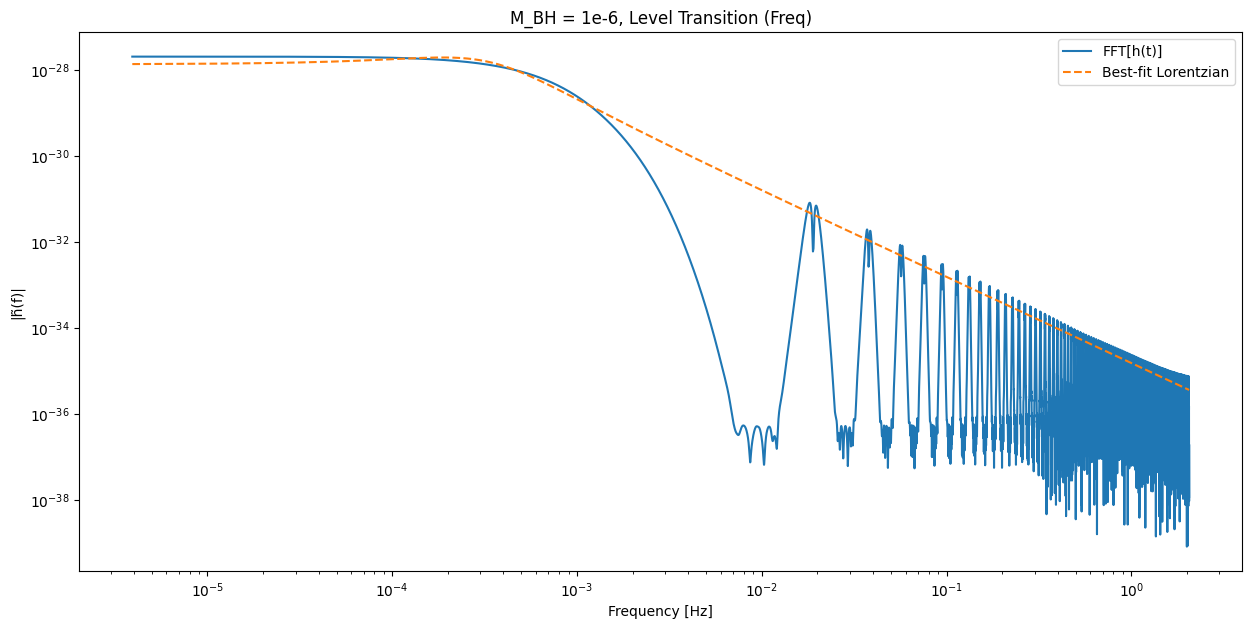

In [2]:
result = iso_gatom_level_tr_strain(
    M_solar=1e-6,
    a_spin=0.999999,
    alpha = 0.75,
    ne=6,
    ng=5,
    distance_kpc=1.0,
    verbose=True,
)

print(result.keys())
# Freq Axis

f = result["f_pos"]
# FFT of time domain strain
H = result["H_pos"]
# Fitted Lorentzian
L = result["L_full"]

# quick plot if you want
plt.figure(figsize=(15, 7))
plt.title('M_BH = 1e-6, Level Transition (Freq)')
plt.loglog(f, np.abs(H), label='FFT[h(t)]')
plt.loglog(f, L, '--', label='Best-fit Lorentzian')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|h̃(f)|')
plt.legend()
plt.show()

# Associated Time Domain Strain

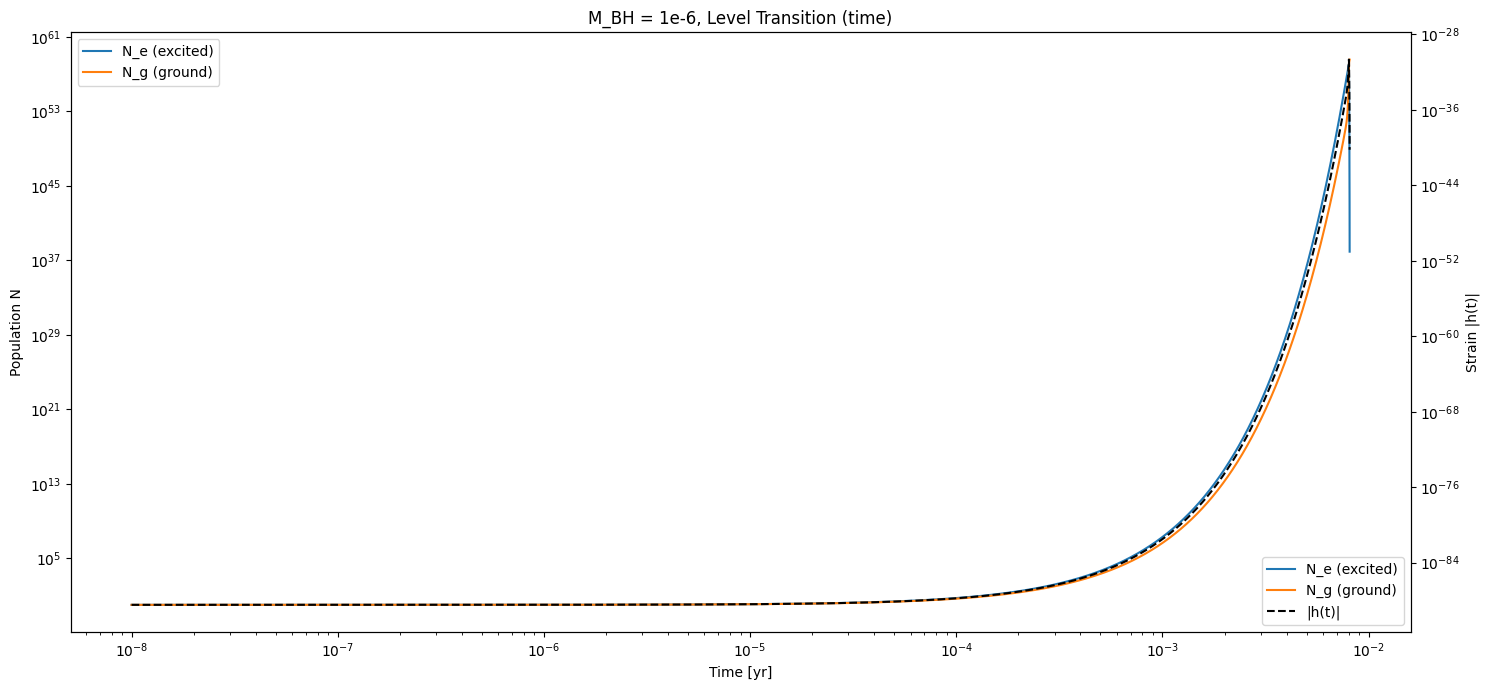

In [3]:

time_yr = result["time_yr"]
h_t     = result["h_t"]
N_e     = result["N_e"]
N_g     = result["N_g"]

fig, ax1 = plt.subplots(figsize=(15, 7))
ax1.set_title('M_BH = 1e-6, Level Transition (time)')
# Populations vs time (left y-axis)
ax1.loglog(time_yr, N_e, label="N_e (excited)")
ax1.loglog(time_yr, N_g, label="N_g (ground)")
# ax1.set_xlim(5e-3,1e-2)
# ax1.set_ylim(1e29,1e61)
ax1.set_xlabel("Time [yr]")
ax1.set_ylabel("Population N")
ax1.legend(loc="upper left")

# Strain vs time (right y-axis)
ax2 = ax1.twinx()
ax2.loglog(time_yr, np.abs(h_t), "k--", label="|h(t)|")
ax2.set_ylabel("Strain |h(t)|")
# ax2.set_ylim(1e-60,1e-28)

# Separate legend for right axis
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

fig.tight_layout()
plt.show()

# Annihilation Level Transition Strain

<>:87: SyntaxWarning: invalid escape sequence '\o'
<>:87: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_133797/1514634364.py:87: SyntaxWarning: invalid escape sequence '\o'
  plt.vlines(f_ann,1e-36, 1e-29, label = f'$\omega_{{ann}}$ = {f_ann/1e6:.3e} MHz', linestyles='--', color = 'orange', alpha = 0.7)


alpha ≈ 4.640e-01
Annihilation line f_ann ≈ 9.607e+07 Hz
max |h_plus| ≈ 8.211e-39
max h_c ≈ 1.591e-30


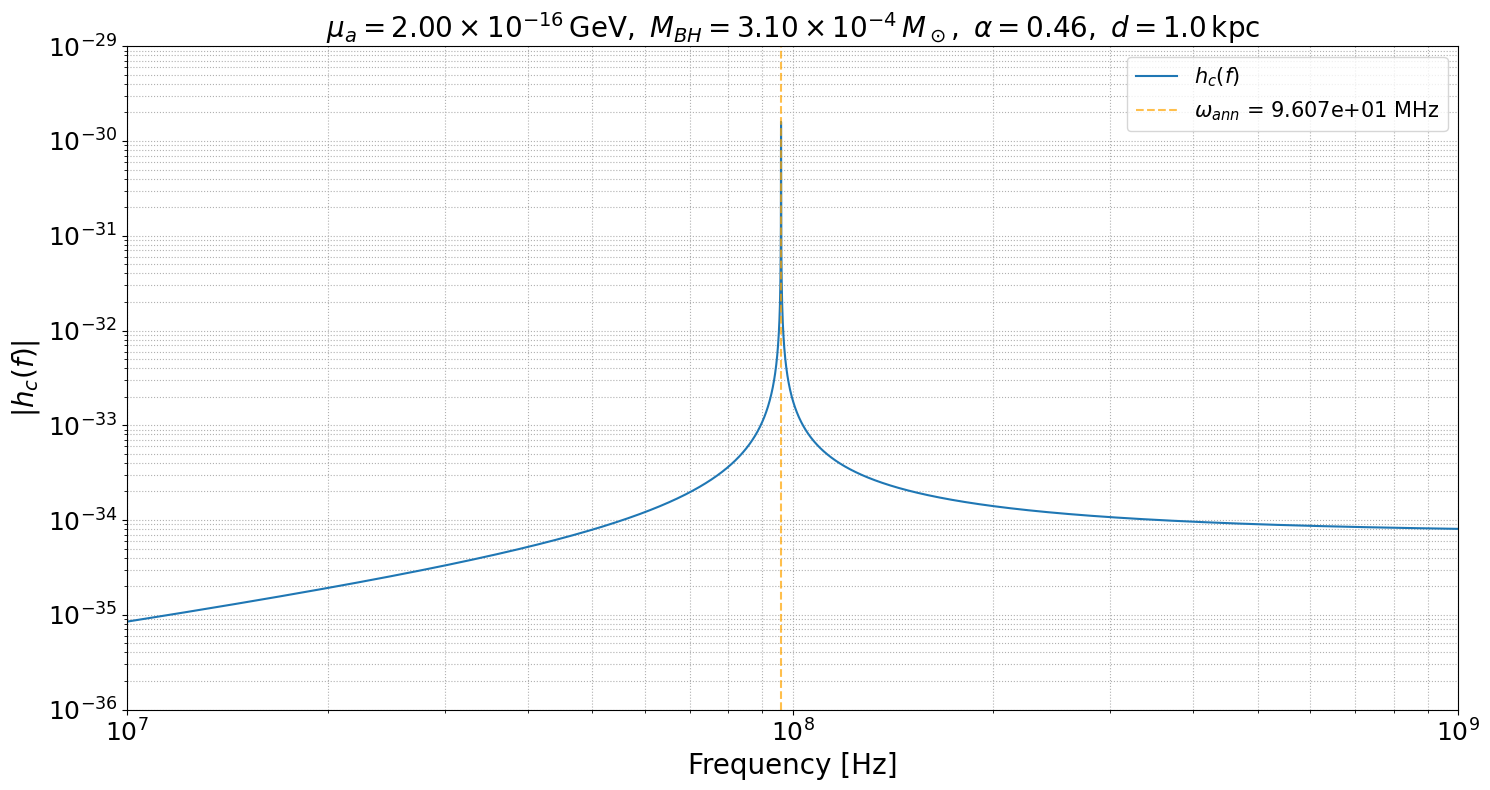

In [4]:
from julia_strain_functions import iso_gatom_ann_strain

# helper to format numbers as A×10^B in LaTeX
def sci_latex(x, precision=2):
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent
    return f"{mantissa:.{precision}f}\\times10^{{{exponent}}}"

# font sizes 
title_fs  = 20
label_fs  = 20
tick_fs   = 18
legend_fs = 15

# ---------------------------------------------------------
# choosen parameters
# ---------------------------------------------------------
M_solar_ann   = 3.1e-4      # BH mass in solar masses
mua_ann       = 2e-16       # boson mass [GeV]
distance_kpc  = 1.0
n_ann         = 4
iota_ann      = 0.0
phase_ann     = 0.0

# frequency range (Hz)
f_min = 1e0
f_max = 1e12
N_f   = 50000

# ---------------------------------------------------------
# call the annihilation master function
# ---------------------------------------------------------
res_ann = iso_gatom_ann_strain(
    M_solar      = M_solar_ann,
    mua          = mua_ann,
    n            = n_ann,
    l            = None,              # default n-1
    alpha        = None,              # let it compute α = G M μ
    distance_kpc = distance_kpc,
    iota         = iota_ann,
    phase        = phase_ann,
    f_min_Hz     = f_min,
    f_max_Hz     = f_max,
    n_f          = N_f,
    verbose      = True,
)

f_Hz     = res_ann["f_Hz"]
h_c      = res_ann["h_c"]
f_ann    = res_ann["f_line_Hz"]
alpha    = res_ann["alpha"]
M_ann = res_ann["M_solar"]
alpha_ann = res_ann["alpha"]
r_kpc = res_ann["distance_kpc"]

# ---------------------------------------------------------
# plot annihilation characteristic strain
# ---------------------------------------------------------
plt.figure(figsize=(15, 8))

plt.plot(
    f_Hz,
    np.abs(h_c),
    label=r'$h_c(f)$'
)

plt.xscale('log')
plt.yscale('log')

# tweak as needed
plt.xlim(1e7, 1e9)
plt.ylim(1e-36, 1e-29)

plt.xlabel('Frequency [Hz]', fontsize=label_fs)
plt.ylabel(r'$|h_c(f)|$', fontsize=label_fs)
plt.tick_params(axis='both', which='both', labelsize=tick_fs)

plt.title(
    r'$\mu_a = {}\,\mathrm{{GeV}},\ $'.format(sci_latex(mua_ann)) +
    r'$M_{{BH}} = {}\,M_\odot,\ $'.format(sci_latex(M_ann)) +
    r'$\alpha = {:.2f},\ d = {:.1f}\,\mathrm{{kpc}}$'.format(alpha_ann, r_kpc),
    fontsize=title_fs
)
# vertical line at annihilation line frequency
plt.vlines(f_ann,1e-36, 1e-29, label = f'$\omega_{{ann}}$ = {f_ann/1e6:.3e} MHz', linestyles='--', color = 'orange', alpha = 0.7)


plt.grid(True, which='both', ls=':')
plt.legend(fontsize=legend_fs)

plt.tight_layout()
plt.show()